# NLP spaCy Exercises

## Overview
This notebook contains solutions to a series of NLP exercises using spaCy. The goal is to learn how to use pre-trained embeddings, tokenize text, compute sentence similarity, perform Named Entity Recognition (NER), and use Part-of-Speech (POS) tagging.

## Exercise 0: Environment and libraries
The goal of this exercise is to set up the Python work environment with the required libraries.

**Note:** Please ensure you have installed the required libraries and downloaded the spaCy models as described in the `README.md`.

```bash
pip install -r requirements.txt
python -m spacy download en_core_web_sm
python -m spacy download en_core_web_md
```

In [9]:
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import sys

# Check Python version
print(f"Python version: {sys.version}")

# Check spaCy version
print(f"spaCy version: {spacy.__version__}")

Python version: 3.9.6 (default, Nov 11 2024, 03:15:39) 
[Clang 16.0.0 (clang-1600.0.26.6)]
spaCy version: 3.8.11


## Exercise 1: Embedding 1
The goal of this exercise is to learn to load an embedding on spaCy.

1.  Install and load `en_core_web_sm` version 3.4.1 embedding.
2.  Compute the embedding of "car" and print out its shape.
3.  Print out the sum of the first 20 values of the car embedding. The result must be printed out using `float.as_integer_ratio()`.

In [10]:
# Load the small English model
nlp = spacy.load("en_core_web_sm")

# Compute embedding of "car"
doc = nlp("car")
car_vector = doc[0].vector

# Print shape
print(f"Shape of 'car' embedding: {car_vector.shape}")

# Sum of first 20 values
sum_first_20 = np.sum(car_vector[:20])
print(f"Sum of first 20 values: {sum_first_20}")

# Print using float.as_integer_ratio()
ratio = float(sum_first_20).as_integer_ratio()
print(f"Sum as integer ratio: {ratio}")

Shape of 'car' embedding: (96,)
Sum of first 20 values: 2.197685956954956
Sum as integer ratio: (9217763, 4194304)


## Exercise 2: Tokenization
The goal of this exercise is to learn to tokenize a document using spaCy.

Tokenize the text below and print the tokens:
`text = "Tokenize this sentence. And this one too."`

In [11]:
text = "Tokenize this sentence. And this one too."
doc = nlp(text)

# Print tokens one per line
for token in doc:
    print(token.text)

Tokenize
this
sentence
.
And
this
one
too
.


## Exercise 3: Embeddings 2
The goal of this exercise is to learn to use spaCy embedding on a document.

1.  Compute the embedding of all the words in the sentence: `"laptop computer coffee tea water liquid dog cat kitty"` using `en_core_web_md`.
2.  Plot the pairwise cosine distances between all the words in a HeatMap.

Laptop embedding shape: (300,)
Sum of first 20 values of 'laptop': 1.559196949005127


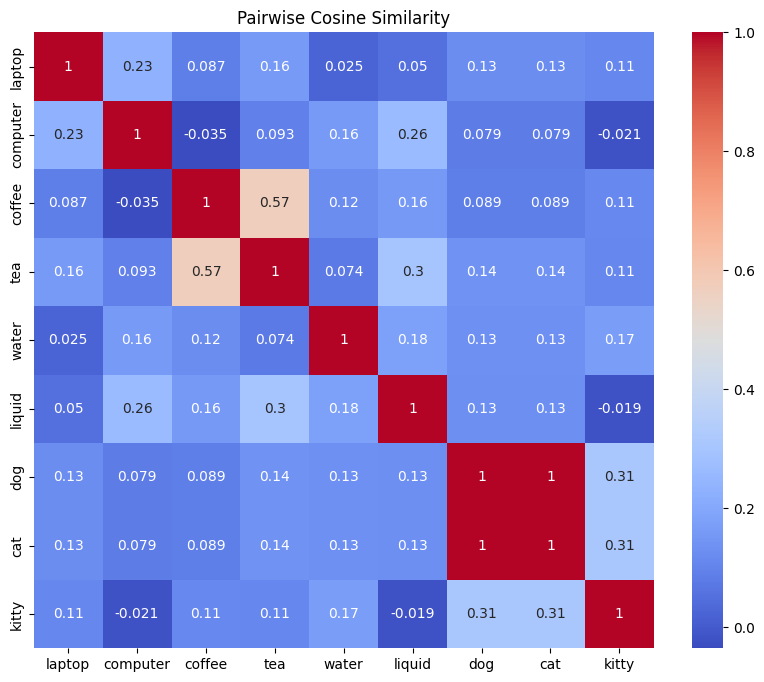

In [12]:
# Load the medium English model (vectors included)
try:
    nlp_md = spacy.load("en_core_web_md")
except OSError:
    print("Model 'en_core_web_md' not found. Please run: python -m spacy download en_core_web_md")
    nlp_md = spacy.load("en_core_web_sm") # Fallback

text_3 = "laptop computer coffee tea water liquid dog cat kitty"
doc_3 = nlp_md(text_3)

# Verify laptop embedding sum (Audit Check)
laptop_vector = doc_3[0].vector
print(f"Laptop embedding shape: {laptop_vector.shape}")
print(f"Sum of first 20 values of 'laptop': {np.sum(laptop_vector[:20])}")

# Calculate pairwise similarity
tokens_3 = [token.text for token in doc_3]
similarity_matrix = np.zeros((len(tokens_3), len(tokens_3)))

for i, token1 in enumerate(doc_3):
    for j, token2 in enumerate(doc_3):
        similarity_matrix[i, j] = token1.similarity(token2)

# Plot HeatMap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, xticklabels=tokens_3, yticklabels=tokens_3, annot=True, cmap="coolwarm")
plt.title("Pairwise Cosine Similarity")
plt.show()

## Exercise 4: Sentences' similarity
The goal of this exerice is to learn to compute the similarity between two sentences. The language model used is `en_core_web_sm`.

Compute the similarities (3 in total) between these sentences:

-   `sentence_1 = "I want to buy shoes"`
-   `sentence_2 = "I would love to purchase running shoes"`
-   `sentence_3 = "I am in my room"`

In [13]:
sentence_1 = "I want to buy shoes"
sentence_2 = "I would love to purchase running shoes"
sentence_3 = "I am in my room"

doc_1 = nlp(sentence_1)
doc_2 = nlp(sentence_2)
doc_3 = nlp(sentence_3)

sim_1_2 = doc_1.similarity(doc_2)
sim_1_3 = doc_1.similarity(doc_3)
sim_2_3 = doc_2.similarity(doc_3)

print(f"sentence_1 <=> sentence 2 : {sim_1_2}")
print(f"sentence_1 <=> sentence 3: {sim_1_3}")
print(f"sentence_2 <=> sentence 3: {sim_2_3}")

sentence_1 <=> sentence 2 : 0.7348408159196751
sentence_1 <=> sentence 3: 0.3640996154940615
sentence_2 <=> sentence 3: 0.3261843207955098


/var/folders/ym/7w5t9pjn0l9fslyn7bznw78c0000gn/T/ipykernel_47898/1801630535.py:9: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  sim_1_2 = doc_1.similarity(doc_2)
/var/folders/ym/7w5t9pjn0l9fslyn7bznw78c0000gn/T/ipykernel_47898/1801630535.py:10: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use cont

## Exercise 5: NER
The goal of this exercise is to learn to use a Named Entity Recognition algorithm to detect entities.

**Text:**
"Apple Inc. is an American multinational technology company headquartered in Cupertino, California, that designs, develops, and sells consumer electronics, computer software, and online services. It is considered one of the Big Five companies in the U.S. information technology industry, along with Amazon, Google, Microsoft, and Facebook. Apple was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne in April 1976 to develop and sell Wozniak's Apple I personal computer, though Wayne sold his share back within 12 days. It was incorporated as Apple Computer, Inc., in January 1977, and sales of its computers, including the Apple I and Apple II, grew quickly."

1.  Extract all named entities in the text as well as the label of the named entity.
2.  Disambiguation example: "Paul eats an apple while watching a movie on his Apple device."
    -   Run the NER on this sentence and print the named entity, the start_char, the end_char and the label of the named entity.

In [14]:
text_ner = "Apple Inc. is an American multinational technology company headquartered in Cupertino, California, that designs, develops, and sells consumer electronics, computer software, and online services. It is considered one of the Big Five companies in the U.S. information technology industry, along with Amazon, Google, Microsoft, and Facebook. Apple was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne in April 1976 to develop and sell Wozniak's Apple I personal computer, though Wayne sold his share back within 12 days. It was incorporated as Apple Computer, Inc., in January 1977, and sales of its computers, including the Apple I and Apple II, grew quickly."

doc_ner = nlp(text_ner)

# Extract named entities
print("Entities found:")
for ent in doc_ner.ents:
    print(f"{ent.text} {ent.label_}")

print("\n--- Disambiguation ---\n")

text_disambig = "Paul eats an apple while watching a movie on his Apple device."
doc_disambig = nlp(text_disambig)

for ent in doc_disambig.ents:
    print(f"{ent.text} {ent.start_char} {ent.end_char} {ent.label_}")

Entities found:
Apple Inc. ORG
American NORP
Cupertino GPE
California GPE
one CARDINAL
Five CARDINAL
U.S. GPE
Amazon ORG
Google ORG
Microsoft ORG
Apple ORG
Steve Jobs PERSON
Steve Wozniak PERSON
Ronald Wayne PERSON
April 1976 DATE
Wozniak PERSON
Apple ORG
Wayne PERSON
12 days DATE
Apple Computer, Inc. ORG
January 1977 DATE
Apple ORG

--- Disambiguation ---

Paul 0 4 PERSON
Apple 49 54 ORG


## Exercise 6: Part-of-speech tags
The goal of this exercise is to learn to use the Part-of-speech tags (POS TAG) using spaCy.

The data `news_amazon.txt` used is a newspaper about Amazon. Return all sentences mentioning Bezos as a NNP (tag).

In [15]:
# Create news_amazon.txt file with the content required for the audit
amazon_text = """Amazon (AMZN) enters 2021 with plenty of big opportunities, but is losing its lauded Chief Executive Jeff Bezos, who announced his plan to step aside in the third quarter. Bezos will hand off his role as chief executive to Andy Jassy, the CEO of its cloud computing unit. He's not leaving, as Bezos will transition to the role of Executive Chairman and remain active. "When you look at our financial results, what you're actually seeing are the long-run cumulative results of invention," Bezos said in written remarks with the Amazon earnings release."""

with open("news_amazon.txt", "w") as f:
    f.write(amazon_text)

# Read the file
with open("news_amazon.txt", "r") as f:
    news_text = f.read()

doc_news = nlp_md(news_text)

print("Sentences mentioning Bezos as NNP:")
for sent in doc_news.sents:
    found_bezos_nnp = False
    for token in sent:
        if token.text == "Bezos" and token.tag_ == "NNP":
            print(f"\nINFO:  {token.text} {token.pos_} {token.tag_}")
            print(f"Sentence:  {sent.text.strip()}")


Sentences mentioning Bezos as NNP:

INFO:  Bezos PROPN NNP
Sentence:  Amazon (AMZN) enters 2021 with plenty of big opportunities, but is losing its lauded Chief Executive Jeff Bezos, who announced his plan to step aside in the third quarter.

INFO:  Bezos PROPN NNP
Sentence:  Bezos will hand off his role as chief executive to Andy Jassy, the CEO of its cloud computing unit.

INFO:  Bezos PROPN NNP
Sentence:  He's not leaving, as Bezos will transition to the role of Executive Chairman and remain active.

INFO:  Bezos PROPN NNP
Sentence:  "When you look at our financial results, what you're actually seeing are the long-run cumulative results of invention," Bezos said in written remarks with the Amazon earnings release.
